In [1]:
import pandas as pd

train_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/plain_text/train-00000-of-00001.parquet").sample(1000)
test_df = pd.read_parquet("hf://datasets/stanfordnlp/imdb/plain_text/test-00000-of-00001.parquet").sample(1000)

In [2]:
train_df.head()

,text,label
15158,"Brothers with psychokinetic powers (yes, reall...",1
1476,"No wonder that the historian Ian Kershaw, auth...",0
13050,I was surprised at the low rating this film go...,1
3107,Obnoxious Eva Longoria dies on her wedding day...,0
24535,Some of the background details of this story a...,1


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score

In [4]:
model = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', LogisticRegression()),
])

model.fit(train_df['text'], train_df['label'])

/home/tiago/insper/nlp_course/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('vectorizer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [5]:
y_pred = model.predict(test_df['text'])
acc = accuracy_score(y_pred, test_df['label'])
print(acc)

0.774


# Exemplo no PyTorch

In [9]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_df['text']).toarray()
X_test = vectorizer.transform(test_df['text']).toarray()

In [10]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from tqdm import tqdm

In [11]:
X_tensor_train = torch.tensor(X_train).float()
X_tensor_test = torch.tensor(X_test).float()
y_tensor_train = torch.tensor(train_df['label'].values).float().reshape( (-1,1) )
y_tensor_test = torch.tensor(test_df['label'].values).float().reshape( (-1,1) )

In [12]:
X_tensor_train.shape

torch.Size([1000, 18079])

In [13]:
model = nn.Linear(
    in_features=X_tensor_train.shape[1],
    out_features=1,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)  # lr is the learning rate - this is our alpha

print("Entering loop")
# And now, this is the training loop:
losses = []
for epoch in tqdm(range(10000)):
    optimizer.zero_grad()
    z_pred = model(X_tensor_train)
    loss = F.binary_cross_entropy_with_logits(z_pred, y_tensor_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

Entering loop


100%|██████████| 10000/10000 [00:55<00:00, 180.07it/s]


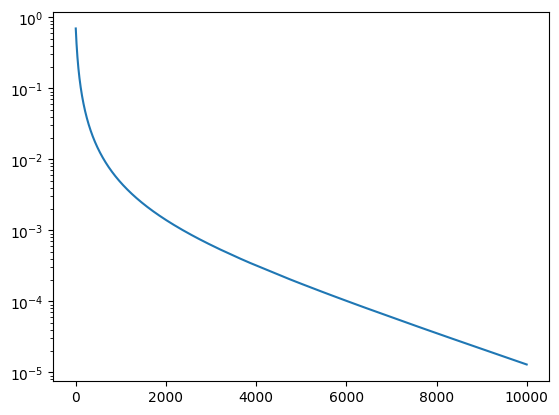

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.semilogy()
plt.show()

In [21]:
z_pred = model(X_tensor_test)
y_class = z_pred > 0.0
y_np = y_class.numpy()

In [22]:
accuracy_score(y_np, test_df['label'])

0.749

In [30]:
import re 

def calcular_vocabulario(textos : list[str]):
    vocabulario = []
    for s in textos:
        palavras = re.findall(r'\w\w+', s.upper())
        vocabulario.extend(palavras)
    return set(vocabulario)

vocabulario = calcular_vocabulario(list(train_df['text']))

def calcular_mapeamento(vocabulario : set[str]):
    mapa = {}
    id = 1
    for w in vocabulario:
        mapa[w] = id
        id += 1
    return mapa

mapa = calcular_mapeamento(vocabulario=vocabulario)
print(mapa)

{'RADIOACTIVE': 1, 'RIDICULOUS': 2, 'EXPECTANT': 3, 'REVEREND': 4, 'TRAIL': 5, 'VALIDATING': 6, 'SETTLES': 7, 'CANDIDATE': 8, 'WESTERNS': 9, 'UNDERLYING': 10, 'ENDORSE': 11, 'PAINTS': 12, 'SOPHOMORIC': 13, 'CUPID': 14, 'DOCUMENTARIES': 15, 'GUNBUSTER': 16, 'DEBTS': 17, 'LOEB': 18, 'SHOWN': 19, 'NASA': 20, 'SHOLAY': 21, 'OATES': 22, 'JOYOUS': 23, 'NEWCOMER': 24, 'SCOTISH': 25, 'THROAT': 26, 'REFLECTS': 27, 'MINDSET': 28, 'MARTINO': 29, 'DISABLED': 30, 'STUNK': 31, 'CRIMSON': 32, 'MULTITUDE': 33, 'REBELLION': 34, '81': 35, 'ELEPHANTS': 36, 'ROMANCES': 37, 'THRILLED': 38, 'JOHNNY': 39, 'SATISFIED': 40, 'REPEATED': 41, 'FLICKERS': 42, 'SUSPECTED': 43, 'PATRONAGE': 44, 'BERNSEN': 45, 'KAPTURE': 46, 'ECSTACY': 47, 'BAT': 48, 'PAMPHLETS': 49, 'DEGRADED': 50, 'ARDENT': 51, 'STRUNG': 52, 'STICKED': 53, 'TENDER': 54, 'IMPENETRABLE': 55, 'INTERVIEWS': 56, 'TRAINING': 57, 'SHRIEK': 58, 'TCM': 59, 'REFORMERS': 60, 'LATCH': 61, 'DORIS': 62, 'NEIGHBORHOOD': 63, 'LURKING': 64, 'PACKARD': 65, 'MALLE': 

In [34]:
def converter_string(texto_de_entrada, mapa, tamanho_saida):
    saida = []
    for s in re.findall(r'\w\w+', texto_de_entrada.upper()):
        if s in mapa:
            saida.append(mapa[s])
        
    if len(saida) < tamanho_saida:
        saida.extend( [0] * (tamanho_saida-len(saida)))
    if len(saida) > tamanho_saida:
        saida = saida[0:tamanho_saida]
    return saida

converter_string("I like this movie ANTIQUITIES MERCILESSLY", mapa, 10)

[14343, 16971, 15340, 0, 0, 0, 0, 0, 0, 0]

In [36]:
mapa['MOVIE']

15340

In [38]:
len(mapa)

18079

In [37]:
mapa['MOVIE']

15340

In [58]:
class MinhaClasse:
    def __init__(self, test):
        print(test)
        self.string = test
    
    def meu_metodo(self):
        print(self.string)
        

x = MinhaClasse("minha string")

y = MinhaClasse("outra string")
x.meu_metodo()
y.meu_metodo()

minha string
outra string
minha string
outra string


In [39]:
class ClassificadorComEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, n_outputs=1):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
        )
        
        self.linear = nn.Linear(
            in_features = embedding_dim,
            out_features=n_outputs
        )
    
    def forward(self, X):
        Xe = self.embedding(X)
        Xp = torch.mean(Xe, dim=1)
        z = self.linear(Xp)
        return z

In [43]:
def tokenizacao(meu_dataset: list[str], mapa, n_tokens):
    saida = []
    for s in meu_dataset:
        saida.append(converter_string(s, mapa, n_tokens))
    return torch.tensor(saida)


toy_data = [
    "this is one way to say it",
    "this is another way to say it movie movie movie",
]


x = tokenizacao(toy_data, mapa, 10)

In [46]:
model = ClassificadorComEmbedding(
    num_embeddings=len(mapa)+1,
    embedding_dim=3,
    )

model(x)
model.embedding(x)

tensor([[[ 2.8019, -0.7523,  0.4209],
         [-0.7320, -0.8727,  0.6194],
         [ 0.0230, -0.8605, -0.7805],
         [-0.9518,  0.6762,  0.8862],
         [-0.6341, -0.5651,  0.7554],
         [-1.7355,  1.0464, -0.9336],
         [ 2.3314, -0.5739, -0.3577],
         [ 2.2513, -0.5916, -1.2983],
         [ 2.2513, -0.5916, -1.2983],
         [ 2.2513, -0.5916, -1.2983]],

        [[ 2.8019, -0.7523,  0.4209],
         [-0.7320, -0.8727,  0.6194],
         [ 0.7564, -0.1987, -0.4471],
         [-0.9518,  0.6762,  0.8862],
         [-0.6341, -0.5651,  0.7554],
         [-1.7355,  1.0464, -0.9336],
         [ 2.3314, -0.5739, -0.3577],
         [-0.9241, -0.8514,  0.1534],
         [-0.9241, -0.8514,  0.1534],
         [-0.9241, -0.8514,  0.1534]]], grad_fn=<EmbeddingBackward0>)

In [47]:
X_train = tokenizacao(train_df['text'], mapa, 100)
model = ClassificadorComEmbedding(20000, 2, 1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)  # lr is the learning rate - this is our alpha

print("Entering loop")
# And now, this is the training loop:
losses = []
for epoch in tqdm(range(10000)):
    optimizer.zero_grad()
    z_pred = model(X_train)
    loss = F.binary_cross_entropy_with_logits(z_pred, y_tensor_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

Entering loop


100%|██████████| 10000/10000 [01:23<00:00, 120.23it/s]


In [48]:
X_test_tokens = tokenizacao(test_df['text'], mapa, 100)
z_test = model(X_test_tokens)
y_test_pred = z_test > 0.0
y_test_pred_np = y_test_pred.numpy().reshape(-1)
accuracy_score(y_test_pred_np, test_df['label'])


0.677

In [52]:
tokens = tokenizacao(["i hate this movie", "i like this movie, it is amazing", "i love this movie"], mapa, 10)
z = model(tokens)


In [53]:
print(z)

tensor([[-8.1045],
        [ 5.7117],
        [-0.3178]], grad_fn=<AddmmBackward0>)


In [54]:
tokens = tokenizacao(["hate", "terrible", "horrible", "amazing", "wonderful", "awesome"], mapa, 10)
z = model(tokens)
print(z)

tensor([[-5.6461],
        [-6.8075],
        [-5.5604],
        [ 3.1284],
        [ 2.0591],
        [ 3.2946]], grad_fn=<AddmmBackward0>)


In [ ]:
embeddings = model.embedding(tokens)[:,0,:]


torch.Size([6, 2])

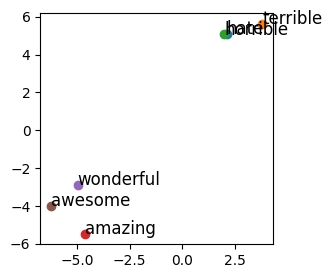

In [62]:
plt.figure(figsize=(3,3))
palavras = ["hate", "terrible", "horrible", "amazing", "wonderful", "awesome"]

for t in range(len(palavras)):
    plt.scatter(embeddings[t,0].item(), embeddings[t,1].item())
    plt.text(embeddings[t,0].item(), embeddings[t,1].item(), palavras[t],fontsize=12)

plt.show()